In [3]:

import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Configuración GPU ()
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ['TF_GPU_THREAD_MODE'] = 'gpu_private'
os.environ['TF_GPU_THREAD_COUNT'] = '1'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU falla ")
    sys.exit(1)

import pandas as pd
import numpy as np
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from transformers import AutoTokenizer, TFBertModel
import matplotlib.pyplot as plt

# Rutas y parámetros
RUTA_CSV = "/home/esebas/Escritorio/Sebas/IA SAMSUNG/PROYECTO/datasets/text_and_description_dataset.csv"
RUTA_IMAGENES = "/home/esebas/Escritorio/Sebas/IA SAMSUNG/PROYECTO/extraccion memes/ALL MEMES"

MAX_LEN = 128
BATCH_SIZE = 16
IMG_SIZE = 224
EPOCHS = 60
INIT_LR = 3e-5
MIN_LR = 1e-7

L2_REG = 0.00005
DROPOUT_MAIN = 0.4
DROPOUT_FINAL = 0.3

CNN_TRAINABLE_LAYERS = 18
BERT_TRAINABLE_LAYERS = 2

2026-02-02 11:39:47.181176: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# Carga y preparacion de datos
df = pd.read_csv(RUTA_CSV)
df['extracted_text'] = df['extracted_text'].fillna('')
df['description_es_new'] = df['description_es_new'].fillna('')
df['text_final'] = df.apply(
    lambda row: f"MEME: {row['extracted_text'][:200]} [SEP] ESCENA: {row['description_es_new'][:300]}",
    axis=1
)

# División estratificada
df_train, df_val = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df['harmless']
)

# Tokenización BERT (BERTO en castellano :D)
tokenizer = AutoTokenizer.from_pretrained('dccuchile/bert-base-spanish-wwm-cased')
def tokenize_batch(texts, batch_size=32):
    tokens = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        tokenized = tokenizer(batch, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors="tf")
        tokens.append(tokenized)
    input_ids = tf.concat([t['input_ids'] for t in tokens], axis=0)
    attention_mask = tf.concat([t['attention_mask'] for t in tokens], axis=0)
    return {'input_ids': input_ids, 'attention_mask': attention_mask}

t_train = tokenize_batch(df_train['text_final'].tolist())
t_val = tokenize_batch(df_val['text_final'].tolist())

# Data augmentation
data_aug_train = tf.keras.Sequential([
    layers.RandomRotation(0.1, fill_mode='constant', fill_value=0),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.1),
    layers.RandomFlip("horizontal"),
])
data_aug_val = tf.keras.Sequential([]) 

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
I0000 00:00:1770028806.047323    4597 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4148 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
# Pipeline de imágenes
def build_image_pipeline(augmenter, training=False):
    def process_single(path, ids, mask, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        if training and augmenter.layers:
            img = augmenter(tf.expand_dims(img, 0))[0]
        img = tf.keras.applications.efficientnet.preprocess_input(img)
        return {"img_input": img, "ids_input": ids, "mask_input": mask}, label
    return process_single

AUTOTUNE = tf.data.AUTOTUNE

train_paths = [os.path.join(RUTA_IMAGENES, str(mid)) for mid in df_train['meme_id']]
train_labels = df_train['harmless'].values.astype('float32')
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, t_train['input_ids'], t_train['attention_mask'], train_labels))
train_ds = train_ds.shuffle(buffer_size=min(2000, len(df_train)), reshuffle_each_iteration=True).map(
    build_image_pipeline(data_aug_train, training=True), num_parallel_calls=AUTOTUNE, deterministic=False
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_paths = [os.path.join(RUTA_IMAGENES, str(mid)) for mid in df_val['meme_id']]
val_labels = df_val['harmless'].values.astype('float32')
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, t_val['input_ids'], t_val['attention_mask'], val_labels))
val_ds = val_ds.map(build_image_pipeline(data_aug_val, training=False), num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [6]:
# Arquitectura multimodal
def build_powerful_model():
    img_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='img_input')
    cnn_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    cnn_base.trainable = True
    for i, layer in enumerate(cnn_base.layers):
        layer.trainable = (i >= len(cnn_base.layers) - CNN_TRAINABLE_LAYERS)
    cnn_features = cnn_base(img_input)
    gap = layers.GlobalAveragePooling2D()(cnn_features)
    gmp = layers.GlobalMaxPooling2D()(cnn_features)
    visual_features = layers.Concatenate()([gap, gmp])
    visual_proj = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2_REG), kernel_initializer='he_normal')(visual_features)
    visual_proj = layers.BatchNormalization()(visual_proj)
    visual_proj = layers.Dropout(DROPOUT_MAIN)(visual_proj)

    ids_input = layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name='ids_input')
    mask_input = layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name='mask_input')
    bert_base = TFBertModel.from_pretrained('dccuchile/bert-base-spanish-wwm-cased')
    bert_base.trainable = True
    for i, layer in enumerate(bert_base.bert.encoder.layer):
        layer.trainable = (i >= len(bert_base.bert.encoder.layer) - BERT_TRAINABLE_LAYERS)
    bert_outputs = bert_base(ids_input, attention_mask=mask_input)
    pooler_output = bert_outputs.pooler_output
    cls_token = bert_outputs.last_hidden_state[:, 0, :]
    mask_expanded = tf.cast(tf.expand_dims(mask_input, -1), tf.float32)
    mean_pooling = tf.reduce_sum(bert_outputs.last_hidden_state * mask_expanded, axis=1) / (tf.reduce_sum(mask_expanded, axis=1) + 1e-9)
    textual_features = layers.Concatenate()([pooler_output, cls_token, mean_pooling])
    textual_proj = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2_REG), kernel_initializer='he_normal')(textual_features)
    textual_proj = layers.BatchNormalization()(textual_proj)
    textual_proj = layers.Dropout(DROPOUT_MAIN)(textual_proj)

    # Fusión simple y atención
    elementwise_product = layers.Multiply()([visual_proj, textual_proj])
    visual_importance = layers.Dense(1, activation='sigmoid')(visual_proj)
    textual_importance = layers.Dense(1, activation='sigmoid')(textual_proj)
    visual_attended = layers.Multiply()([visual_proj, visual_importance])
    textual_attended = layers.Multiply()([textual_proj, textual_importance])
    feature_diff = layers.Subtract()([visual_proj, textual_proj])
    feature_sum = layers.Add()([visual_proj, textual_proj])
    fused_features = layers.Concatenate()([visual_attended, textual_attended, elementwise_product, feature_diff, feature_sum])

    # Capas de decisión
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2_REG * 0.5), kernel_initializer='he_normal')(fused_features)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_FINAL)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2_REG * 0.1), kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_FINAL * 0.8)(x)
    output = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = models.Model(inputs=[img_input, ids_input, mask_input], outputs=output, name='modelo_memes4good_powerful')
    optimizer = optimizers.AdamW(learning_rate=INIT_LR, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='ROC')])
    return model

model = build_powerful_model()

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on

In [7]:
# Pesos de clase
y_train = df_train['harmless'].values
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Callbacks
os.makedirs('./checkpoints', exist_ok=True)
os.makedirs('./logs', exist_ok=True)
callbacks_list = [
    callbacks.ModelCheckpoint(filepath='./checkpoints/mejor_modelo.keras', monitor='val_auc', mode='max', save_best_only=True, save_weights_only=False),
    callbacks.EarlyStopping(monitor='val_auc', patience=15, min_delta=0.0001, mode='max', restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=MIN_LR, mode='min', min_delta=0.001)
]

Epoch 1/60


E0000 00:00:1769998497.633296   42222 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodelo_MEMES4GOOD_v4/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-02-02 03:15:01.233115: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-02 03:15:04.264905: I external/local_xla/xla/service/service.cc:163] XLA service 0x75ea1c1da400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-02 03:15:04.264923: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-02-02 03:15:04.279090: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769998504.368176   42315 device_compiler.h:196] Compiled cl

319/319 [==============================] - 145s 350ms/step - loss: 0.9759 - accuracy: 0.5473 - auc: 0.5665 - val_loss: 0.7375 - val_accuracy: 0.6335 - val_auc: 0.6765 - lr: 3.0000e-05
Epoch 2/60
319/319 [==============================] - 104s 326ms/step - loss: 0.7779 - accuracy: 0.6527 - auc: 0.7124 - val_loss: 0.8216 - val_accuracy: 0.6535 - val_auc: 0.7648 - lr: 3.0000e-05
Epoch 3/60
319/319 [==============================] - 105s 328ms/step - loss: 0.6992 - accuracy: 0.6976 - auc: 0.7764 - val_loss: 0.8516 - val_accuracy: 0.6659 - val_auc: 0.8134 - lr: 3.0000e-05
Epoch 4/60
319/319 [==============================] - 105s 328ms/step - loss: 0.6168 - accuracy: 0.7490 - auc: 0.8302 - val_loss: 0.6401 - val_accuracy: 0.7565 - val_auc: 0.8389 - lr: 3.0000e-05
Epoch 5/60
319/319 [==============================] - 104s 327ms/step - loss: 0.5633 - accuracy: 0.7804 - auc: 0.8649 - val_loss: 0.7557 - val_accuracy: 0.7371 - val_auc: 0.8565 - lr: 3.0000e-05
Epoch 6/60
319/319 [================

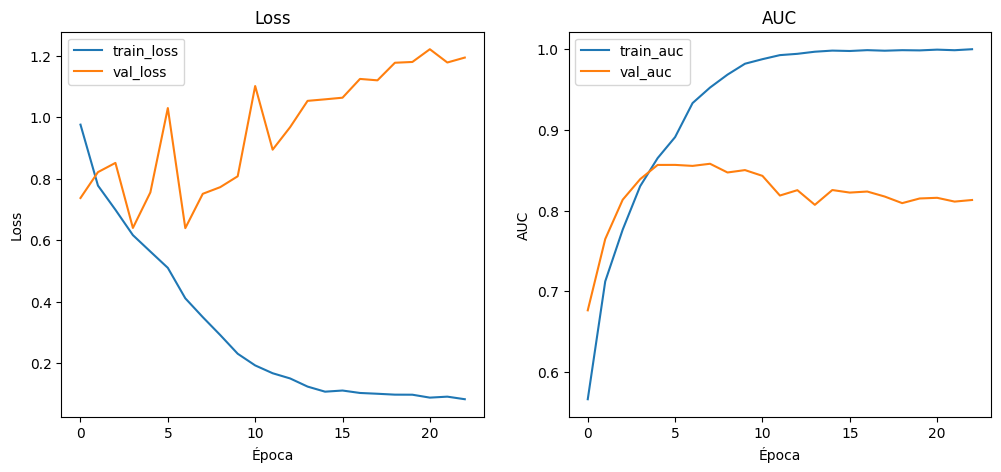

In [6]:
# Entrenamiento
history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, class_weight=class_weight_dict, callbacks=callbacks_list, verbose=1, workers=4, use_multiprocessing=True, max_queue_size=10)

# Guardado final
final_model_path = './modelo_memes4good_POWERFUL.keras'
model.save(final_model_path)
model.save_weights('./modelo_memes4good_POWERFUL_weights.h5')
pd.DataFrame(history.history).to_csv('./training_history_powerful.csv', index=False)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='train_auc')
plt.plot(history.history['val_auc'], label='val_auc')
plt.title('AUC')
plt.xlabel('Época')
plt.ylabel('AUC')
plt.legend()
plt.show()